<a href="https://colab.research.google.com/github/laksamanaap/244107020021-machine-leaning-course-2026-/blob/main/JS05/JS05_TugasLab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [48]:
df = pd.read_csv(
    "./spam.csv",
    encoding="latin1"
)

df.head()
df.shape

df = df[["v1", "v2"]]

df.columns = ["label", "message"]
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [49]:
df["label"].value_counts()

,count
label,
ham,4825
spam,747


In [50]:
## Bagi data training dan testing
X = df["message"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", len(X_train))
print("Data testing :", len(X_test))

Data training: 4457
Data testing : 1115


# Soal 1

In [51]:
## Aktifkan stop words
vectorizer = CountVectorizer(
    stop_words="english"
)

## Buat model Multinomial Naive Bayes
model_count = Pipeline([
    ("vectorizer", CountVectorizer(
        stop_words="english"
    )),

    ("naive_bayes", MultinomialNB())
])


In [52]:
## Training model dan lakukan prediksi
model_count.fit(
    X_train,
    y_train
)

y_pred_count = model_count.predict(X_test)

In [53]:
## Evaluasi akurasi
accuracy_count = accuracy_score(
    y_test,
    y_pred_count
)

print(
    "Akurasi CountVectorizer: {:.2f}%".format(
        accuracy_count * 100
    )
)

Akurasi CountVectorizer: 98.39%


In [54]:
## Clasification report
print(
    classification_report(
        y_test,
        y_pred_count
    )
)

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [55]:
## Confussion matrix
cm_count = confusion_matrix(
    y_test,
    y_pred_count
)

print(cm_count)

[[960   6]
 [ 12 137]]


dari 149 SMS spam, model berhasil mengenali 137 spam.
Ada 12 spam yang salah dianggap sebagai ham

# Soal 2

In [56]:
## Buat TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    stop_words="english"
)

## Buat Model TF-IDF + Naive Bayes
model_tfidf = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english"
    )),

    ("naive_bayes", MultinomialNB())
])


In [57]:
## Training dan prediksi
model_tfidf.fit(
    X_train,
    y_train
)

y_pred_tfidf = model_tfidf.predict(
    X_test
)

In [58]:
## Evaluasi & akurasi
accuracy_tfidf = accuracy_score(
    y_test,
    y_pred_tfidf
)

print(
    "Akurasi TF-IDF: {:.2f}%".format(
        accuracy_tfidf * 100
    )
)

Akurasi TF-IDF: 96.86%


In [59]:
## Classification report TF-IDF
print(
    classification_report(
        y_test,
        y_pred_tfidf
    )
)

              precision    recall  f1-score   support

         ham       0.97      1.00      0.98       966
        spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [60]:
## Confussion Matrix TF-IDF
cm_tfidf = confusion_matrix(
    y_test,
    y_pred_tfidf
)

print(cm_tfidf)

[[966   0]
 [ 35 114]]


In [61]:
## Bandingkan 2 model
hasil = pd.DataFrame({
    "Metode": [
        "CountVectorizer",
        "TF-IDF"
    ],

    "Accuracy": [
        accuracy_count,
        accuracy_tfidf
    ]
})

hasil["Accuracy (%)"] = (
    hasil["Accuracy"] * 100
)

print(hasil)

            Metode  Accuracy  Accuracy (%)
0  CountVectorizer  0.983857     98.385650
1           TF-IDF  0.968610     96.860987


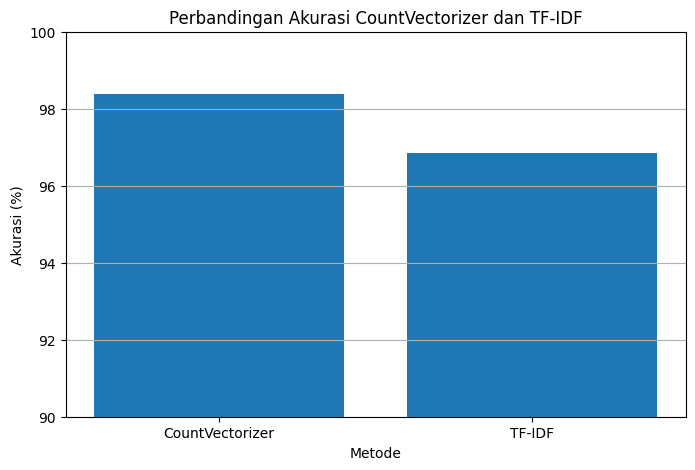

In [62]:
## Grafik perbandingan
plt.figure(figsize=(8, 5))

plt.bar(
    hasil["Metode"],
    hasil["Accuracy (%)"]
)

plt.xlabel("Metode")
plt.ylabel("Akurasi (%)")
plt.title("Perbandingan Akurasi CountVectorizer dan TF-IDF")

plt.ylim(90, 100)
plt.grid(axis="y")

plt.show()

Berdasarkan percobaan klasifikasi pada dataset spam.csv menggunakan Multinomial Naive Bayes, dilakukan perbandingan dua metode ekstraksi fitur, yaitu CountVectorizer dan TF-IDF, dengan mengaktifkan stop words

Pada metode CountVectorizer diperoleh akurasi sebesar 98,39%. Model mampu memperoleh recall sebesar 91,95% dan f1-score sebesar 93,84% pada kelas spam. Sementara itu, penggunaan TF-IDF menghasilkan akurasi sebesar 96,86%, dengan recall kelas spam sebesar 76,51% dan f1-score sebesar 86,69%

Berdasarkan hasil tersebut, CountVectorizer memberikan performa yang lebih baik dibandingkan TF-IDF pada dataset spam.csv. CountVectorizer tidak hanya menghasilkan akurasi yang lebih tinggi, tetapi juga mampu mengenali lebih banyak pesan spam. Oleh karena itu, pada percobaan ini CountVectorizer merupakan fitur yang lebih sesuai untuk klasifikasi pesan spam menggunakan Multinomial Naive Bayes